In [2]:
from IPython.display import display, HTML

html_code = '''
<h1 style="background-color: darkblue;
color: orange;
font-size: 30px;
border-radius: 20px;
padding: 16px;
text-align: center;">

<b style="color: lightblue;">
Python Exploratory Data Analysis
</b> For Student Performance

</h1>
'''

display(HTML(html_code))

In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [4]:
!pip install lightgbm

In [9]:
from IPython.core.display import display, HTML
html_content= '''
<h1 style="background-color: darkblue; color: white; font-size: 30px; border-radius: 20px; padding: 16px; text-align: center;">
<span style="color: lightblue;" > Importing Libraries </span>
<span style="color: orange;" > Student Data</span>
</h1>
'''
display(HTML(html_content))

In [ ]:
#basic
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from IPython.display import clear_output
warnings.filterwarnings('ignore')


In [5]:
#Feature Engineering

import re
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold

In [6]:
#Modeling
import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


In [7]:
# Model Evaluation
from sklearn.metrics import mean_squared_error
rs = 999

In [21]:
from google.colab import files
files.upload()


Saving StudentsPerformance.csv to StudentsPerformance.csv


{'StudentsPerformance.csv': b'"gender","race/ethnicity","parental level of education","lunch","test preparation course","math score","reading score","writing score"\n"female","group B","bachelor\'s degree","standard","none","72","72","74"\n"female","group C","some college","standard","completed","69","90","88"\n"female","group B","master\'s degree","standard","none","90","95","93"\n"male","group A","associate\'s degree","free/reduced","none","47","57","44"\n"male","group C","some college","standard","none","76","78","75"\n"female","group B","associate\'s degree","standard","none","71","83","78"\n"female","group B","some college","standard","completed","88","95","92"\n"male","group B","some college","free/reduced","none","40","43","39"\n"male","group D","high school","free/reduced","completed","64","64","67"\n"female","group B","high school","free/reduced","none","38","60","50"\n"male","group C","associate\'s degree","standard","none","58","54","52"\n"male","group D","associate\'s degre

In [23]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [24]:
df = pd.read_csv("StudentsPerformance.csv")

In [25]:
df.shape

(1000, 8)

In [48]:
from IPython.display import display, HTML

html_code = '''
<h1 style="background-color: darkblue;
color: orange;
font-size: 30px;
border-radius: 20px;
padding: 16px;
text-align: center;">

<span style="color: lightblule;"> Reading </span>
<span style="color: orange;"> Student Data </span>

</h1>
'''

display(HTML(html_code))




In [26]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [33]:
from IPython.display import display, HTML

html_content = '''
<div style="background-color: blue; padding: 16px; border-radius: 10px; text-align: left;">
<span style="color: lightblue;">There are missing values present</span>
<br>
<span style="color: black;">which account for 299 rows,</span>
<br>
<span style="color: black;">approximately 3.466021% of the entire dataset.</span>
<br>
<span style="color: orange;">We will begin by removing the rows containing missing values</span>
</div>
'''

display(HTML(html_content))

In [34]:
df_na = df.dropna()
print(df_na.shape)
df_na.isnull().sum()

(1000, 8)


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [35]:
df_na.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [43]:
df_cleaned = df_na[df_na['math score'] <= 100]
df_cleaned.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [46]:
from IPython.display import display, HTML

html_content = '''
<div style="background-color: blue; padding: 16px; border-radius: 10px; text-align: left;">
<span style="color: lightblue;">Next, we will check the data type of  each column and seprate them into numerical and categorical data types</span>
<br>
<span style="color: orange;">We will convert variables that are actually categorical but were classified as numerical due to their integer data type into categorocal variables</span>
</div>
'''

display(HTML(html_content))

In [41]:
df_cleaned.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [47]:
num_col = ['hours_studeied','Attendance','Previous_Scores']
cat_col = ['Parental_Involvement','Access_to_Resources','sleep_Hours','Extracurricular_Activities','Motivation_Level']
target = 'Exam_Score'

In [83]:
from IPython.display import display, HTML

html_code = '''
<h1 style="background-color: darkblue;
color: orange;
font-size: 30px;
border-radius: 20px;
padding: 16px;
text-align: center;">

<span style="color: lightblue;"> Data Visualization </span>
<span style="color: orange;"> Student Data </span>

</h1>
'''

display(HTML(html_code))

In [82]:
from IPython.display import display, HTML

html_code = '''
<h1 style="background-color: darkblue;
color: orange;
font-size: 30px;
border-radius: 20px;
padding: 16px;
text-align: center;">

<span style="color: lightblue;"> Distribution of target variable </span>
<span style="color: orange;"> (exam_score) </span>

</h1>
'''

display(HTML(html_code))

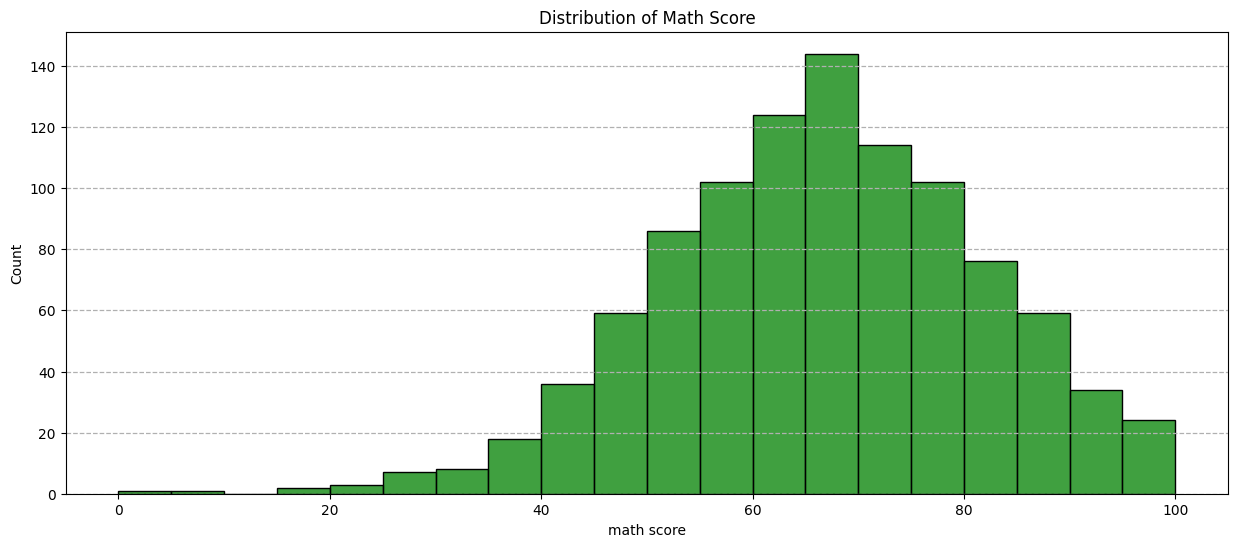

In [57]:

plt.figure(figsize=(15, 6))

sns.histplot(df_cleaned['math score'], bins=20, color='green')

plt.title("Distribution of Math Score")
plt.grid(True, which='major', axis='y', linestyle='--', linewidth=0.9)

plt.show()

In [81]:
from IPython.display import display, HTML

html_code = '''
<h1 style="background-color: darkblue;
color: orange;
font-size: 20px;
border-radius: 20px;
padding: 16px;
text-align: center;">

<span style="color: lightblue;">The bottom 21.8% of scores are under 64, while the top 24.87% scores are over 70,</span>
<span style="color: orange;">50% of the scores are concentrated between 65 and 69.</span>

</h1>
'''

display(HTML(html_code))

In [62]:
a = len(df_cleaned[df_cleaned['math score'] <= 64 ])/ len (df_cleaned['math score']) * 100
b = len(df_cleaned[df_cleaned['math score'] <= 70 ])/ len (df_cleaned['math score']) * 100
c = len(df_cleaned[df_cleaned['math score'] >= 65 ])/ len (df_cleaned['math score']) * 100

print('The Bottom', f'{a:.2f}', '% are under 64')
print('The Top', f'{b:.2f}', '% are under 70')
print('The Middle', f'{c:.2f}', '% are in between 65 and 69')


The Bottom 44.70 % are under 64
The Top 60.90 % are under 70
The Middle 55.30 % are in between 65 and 69


In [80]:
from IPython.display import display, HTML

html_code = '''
<h1 style="background-color: darkblue;
color: orange;
font-size: 20px;
border-radius: 20px;
padding: 16px;
text-align: center;">

<span style="color: lightblue;">We will first implement code that prevents warnings </span>
<span style="color: orange;">about infinite values during visualization</span>

</h1>
'''

display(HTML(html_code))

In [67]:
import numpy as np

df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)
df_cleaned.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [79]:
from IPython.display import display, HTML

html_code = '''
<h1 style="background-color: darkblue;
color: orange;
font-size: 20px;
border-radius: 20px;
padding: 16px;
text-align: center;">

<span style="color: lightblue;">Distribution of </span>
<span style="color: orange;">Numeric Variables</span>

</h1>
'''

display(HTML(html_code))

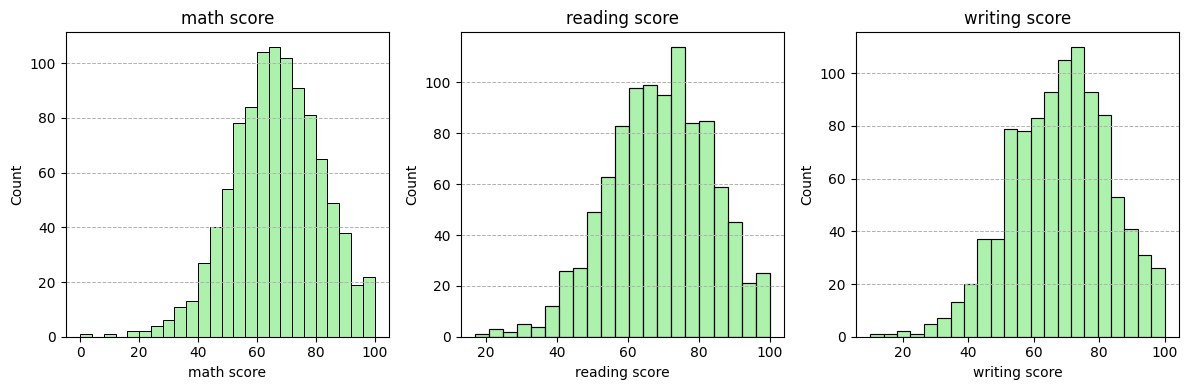

In [71]:
num_col = ['math score', 'reading score', 'writing score']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.ravel()

for idx, col in enumerate(num_col):
    sns.histplot(x=df_cleaned[col], ax=axes[idx], color='lightgreen')
    axes[idx].grid(True, which='major', axis='y', linestyle='--', linewidth=0.7)
    axes[idx].set_title(f"{col}")

plt.tight_layout()
plt.show()


In [78]:
from IPython.display import display, HTML

html_code = '''
<h1 style="background-color: darkblue;
color: orange;
font-size: 20px;
border-radius: 20px;
padding: 16px;
text-align: center;">

<span style="color: lightblue;">-The breaks or gaps in the 'Hours_Studied' variables may be due to respondents answering approximately </span>
<span style="color: orange;">-The variables</span>

</h1>
'''

display(HTML(html_code))

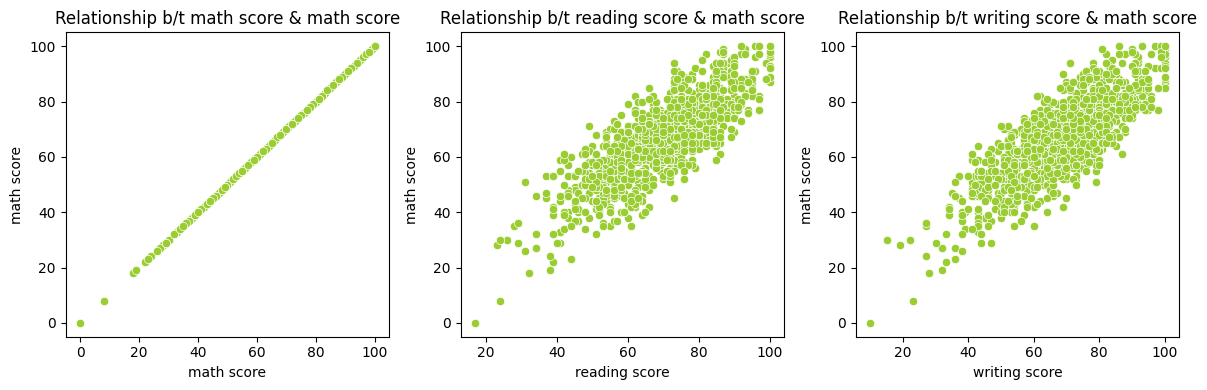

In [75]:
num_col = ['math score', 'reading score', 'writing score']
target = 'math score'   # choose your target

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.ravel()

for idx, col in enumerate(num_col):
    sns.scatterplot(x=df_na[col], y=df_na[target], ax=axes[idx], color='yellowgreen')
    axes[idx].set_title(f'Relationship b/t {col} & {target}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel(target)

plt.tight_layout()
plt.show()

<Axes: >

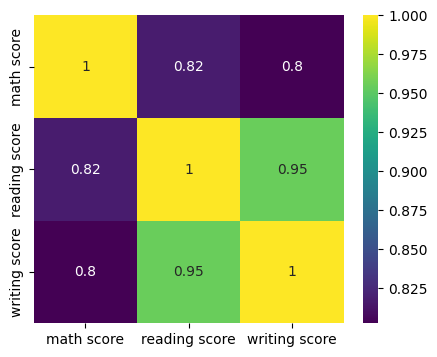

In [77]:
corr_col = ['math score', 'reading score', 'writing score']
df_corr = df_cleaned[corr_col]

corr = df_corr.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='viridis')

In [84]:
from IPython.display import display, HTML

html_code = '''
<h1 style="background-color: darkblue;
color: orange;
font-size: 20px;
border-radius: 20px;
padding: 16px;
text-align: center;">

<span style="color: lightblue;">
- Reading score and Writing score show a strong positive correlation with Math score
</span>
<br>

<span style="color: white;">
- There are some data points that deviate from the overall trend (possible outliers)
</span>
<br>

<span style="color: orange;">
- Test preparation course appears to influence student performance significantly
</span>

</h1>
'''
display(HTML(html_code))

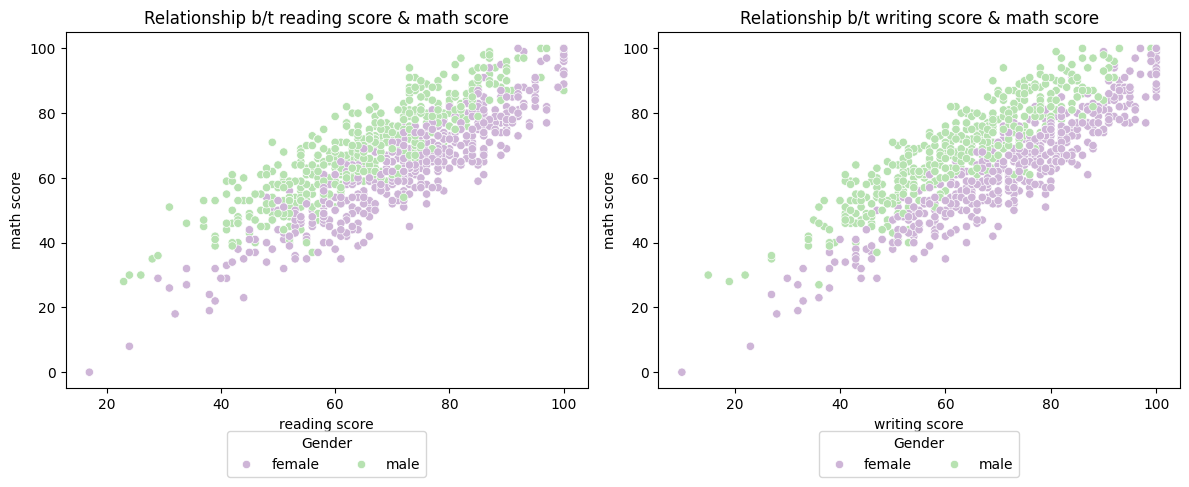

In [87]:
num_col = ['reading score', 'writing score']
target = 'math score'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.ravel()

for idx, col in enumerate(num_col):
    sns.scatterplot(
        x=df_cleaned[col],
        y=df_cleaned[target],
        ax=axes[idx],
        hue=df_cleaned['gender'],
        palette='PRGn'
    )

    axes[idx].set_title(f'Relationship b/t {col} & {target}')
    axes[idx].legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, title='Gender')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel(target)

plt.tight_layout()
plt.show()